In [63]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import skew
import pandas as pd

class DataGeneration():
    def __init__(self, mus=[], sigmas=[], rho=[] , asset_names=None):
        self.mus    = np.array(mus, dtype=float) 
        self.sigmas = np.array(sigmas, dtype=float) 
        self.rho    = np.array(rho, dtype=float)
        D = np.diag(self.sigmas)
        self.covariance = D @ self.rho @ D 
        
        n_assets = self.mus.shape[0]
        self.asset_names =  (asset_names if asset_names is not None \
                            else [f"Asset {i}" for i in range(n_assets)]
        )
        self.Rt = None
    
    def generate(self, T, seed=None):
        if seed is not None:
            np.random.seed(seed)
        self.Rt =  np.random.multivariate_normal( self.mus, self.covariance, size=T)
        return pd.DataFrame(self.Rt, columns=self.asset_names) 
    
    def plot(self, bins=50,filename=None):
        if self.Rt is None: 
            raise RuntimeError("Generate returns before calling plot()")
        n_sim = self.Rt.shape[0]
        
        fig, ax = plt.subplots()

        for i, asset in enumerate(self.asset_names):
            ax.hist(self.Rt[:,i], bins=bins, alpha=0.5, label=fr"{asset} ($\mu$={self.mus[i]:.3f}, $\sigma$={self.sigmas[i]:.3f})")
        ax.set_xlabel("Daily return")
        leg = ax.legend(
            title="Asset name (generation parameters)",
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0)
        leg.get_title().set_fontweight("bold")

        ax.set_title(f"Simulated Asset Return (N={n_sim})")

        if filename is not None:
            fig.savefig(filename, format="png", dpi=150, bbox_inches="tight")
        plt.show()
    
    def summary(self):
        if self.Rt is None: 
            raise RuntimeError("Generate returns before calling summary()")
        #quantiles
        q_low, q_high  = np.percentile(self.Rt, [15.9, 84.1], axis=0)

        results = {
            "mean":   np.mean(self.Rt, axis=0),
            "std":    np.std(self.Rt, axis=0),
            "median": np.median(self.Rt, axis=0),
            "q15.9":  q_low,
            "q84.1":  q_high,
            "skew":   skew(self.Rt, axis=0),
        }
        correlations = np.corrcoef(self.Rt, rowvar=False)
        df_stats = pd.DataFrame(results, index=self.asset_names)
        df_corr  = pd.DataFrame( correlations , index=self.asset_names, columns=self.asset_names)
        return df_stats, df_corr

    def plot_timeseries(self, T_plot=300, filename=None):
        if self.Rt is None:
            raise RuntimeError("Generate returns before calling plot_timeseries().")

        T_plot = min(T_plot, self.Rt.shape[0])
        cum = np.cumsum(self.Rt[:T_plot], axis=0)

        fig, ax = plt.subplots()

        for i, asset in enumerate(self.asset_names):
            ax.plot(cum[:, i], label=asset)

        ax.set_title("One simulated realization of cumulative returns")
        ax.set_xlabel("Time [days]")
        ax.set_ylabel("Cumulative return")
        ax.legend()

        if filename is not None:
            fig.savefig(filename, dpi=150, bbox_inches="tight")

        plt.show()


## Model setup

We consider a universe of three risky assets. Asset returns are characterized by a vector of expected returns and a vector of volatilities, together with a constant correlation structure.

Let  
$\boldsymbol{\mu} \in \mathbb{R}^3$ denote the vector of **expected returns**, and  
$\boldsymbol{\sigma} \in \mathbb{R}^3$ the vector of **return volatilities** (standard deviations).  
The true model parameters are given by

$$
\boldsymbol{\mu} =
\begin{pmatrix}
0.10 \\
0.07 \\
0.04
\end{pmatrix},
\qquad
\boldsymbol{\sigma} =
\begin{pmatrix}
0.25 \\
0.15 \\
0.07
\end{pmatrix}.
$$

Dependence across assets is captured through a constant **correlation matrix**  
$\boldsymbol{\rho} \in \mathbb{R}^{3 \times 3}$, defined as

$$
\boldsymbol{\rho} =
\begin{pmatrix}
1.0 & 0.6 & 0.2 \\
0.6 & 1.0 & 0.3 \\
0.2 & 0.3 & 1.0
\end{pmatrix}.
$$

Together, the vectors $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$, along with the correlation matrix $\boldsymbol{\rho}$, fully characterize the joint second-order structure of asset returns in the model.

In [64]:
mus = [0.10, 0.07, 0.04]
sigmas = [0.25, 0.15, 0.07]
rho = [
    [1.0, 0.6, 0.2],
    [0.6, 1.0, 0.3],
    [0.2, 0.3, 1.0]
]

We generate $10{,}000$ Monte Carlo realizations of the vector of expected returns by sampling from the multivariate normal distribution
$$
\boldsymbol{R_t} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma}),
$$
where $\boldsymbol{\Sigma} = \mathrm{diag}(\boldsymbol{\sigma})\,\boldsymbol{\rho}\,\mathrm{diag}(\boldsymbol{\sigma})$.

In [65]:
gen = DataGeneration(mus, sigmas, rho)
returns = gen.generate(T=10_000, seed=42)

From the sampled distributions, we compute empirical summary statistics, including the mean, standard deviation, median, 34.9% and 84.1% quantiles, and skewness. The empirical estimates are observed to be very close to the true parameter values, as expected given the large number of Monte Carlo realizations.

In [66]:
results_stat, results_corr = gen.summary()
results_stat.round(3)

,mean,std,median,q15.9,q84.1,skew
Asset 0,0.102,0.251,0.103,-0.146,0.350,0.017
Asset 1,0.070,0.149,0.069,-0.078,0.220,-0.014
Asset 2,0.040,0.070,0.039,-0.029,0.111,0.006


In [67]:
results_corr.round(3)

,Asset 0,Asset 1,Asset 2
Asset 0,1.000,0.598,0.216
Asset 1,0.598,1.000,0.312
Asset 2,0.216,0.312,1.000


In real financial datasets, asset prices are observed as time series, and return distributions are estimated *ex post* from these realizations. In this project, we invert this procedure by specifying a return distribution *a priori* and generating synthetic time series that are consistent with it.

For visualization purposes, we consider the cumulative return as a function of time, evaluated up to a horizon of $T = 300$ time steps. The cumulative return trajectories for the assets are plotted to illustrate the temporal evolution implied by the specified return distribution. The resulting figure is saved as `CummulativeAssetReturn.png`.

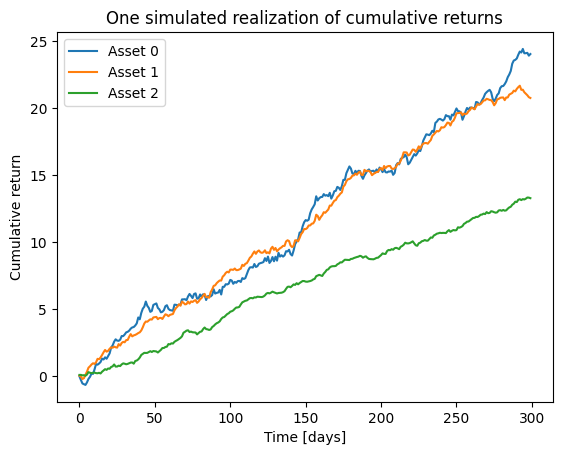

,Asset 0,Asset 1,Asset 2
0,-0.027888,0.020895,0.075851
1,-0.285190,-0.072285,0.002383
2,-0.252412,-0.176179,-0.033603
3,-0.055299,0.062177,0.009326
4,-0.050282,0.256555,-0.038313
...,...,...,...
9995,0.166191,0.144437,0.070584
9996,-0.081795,-0.203921,-0.024313
9997,-0.308305,-0.204971,-0.089515
9998,0.384036,0.249860,0.167365


In [70]:
gen.plot_timeseries(filename="CummulativeAssetReturn.png")
returns

The histograms below show the marginal return distributions implied by the model for each asset. These distributions summarize the behavior of individual return increments that, when accumulated over time, generate the price paths shown previously.

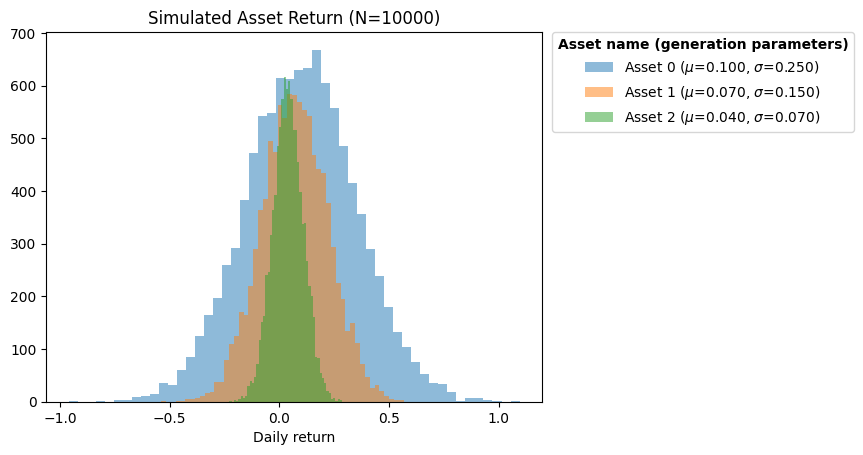

In [71]:
gen.plot(filename="SimulatedAssetReturn.png")
